# 🔬 Data Mining — Lecture 5: Cluster Analysis and Anomaly Detection
### Haydar Kılıç | Artificial Intelligence Engineering

This notebook is the hands-on Python companion to the theoretical content of the lecture slides.  
Each section follows the structure: **Theory → Code → Visualization → Interpretation**.

---



## 0. Library Imports and General Settings


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.cluster import contingency_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

# Visual theme
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PALETTE = ["#2196F3","#E91E63","#4CAF50","#FF9800","#9C27B0","#00BCD4"]
RNG = np.random.default_rng(42)  # modern numpy RNG (reproducibility)
print("✅ All libraries loaded.")


✅ Tüm kütüphaneler yüklendi.


---
## 1. Introduction to Clustering

> **Definition:** Cluster analysis is the process of partitioning data into meaningful groups without label information.  
> Points within the same cluster should be close to each other, while points in different clusters should be far apart.

In the example below, we create and visualize a dataset containing 3 natural clusters.


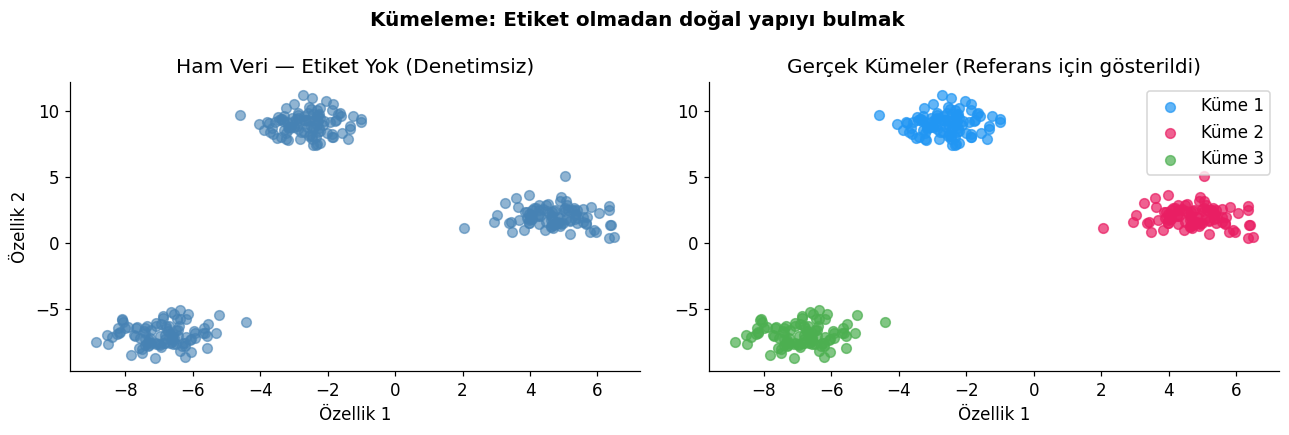

3 doğal küme içeren 300 noktalı veri seti oluşturuldu.


In [2]:
X_intro, y_intro = make_blobs(n_samples=300, centers=3,
                               cluster_std=0.8, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Unlabeled (unsupervised scenario)
axes[0].scatter(X_intro[:, 0], X_intro[:, 1], c="steelblue", alpha=0.6, s=40)
axes[0].set_title("Raw Data — No Labels (Unsupervised)")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")

# Right: True clusters for reference
for k in range(3):
    mask = y_intro == k
    axes[1].scatter(X_intro[mask, 0], X_intro[mask, 1],
                    color=PALETTE[k], alpha=0.7, s=40, label=f"Cluster {k+1}")
axes[1].set_title("True Clusters (shown for reference)")
axes[1].legend(); axes[1].set_xlabel("Feature 1")

plt.suptitle("Clustering: Finding natural structure without labels", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("Dataset with 300 points and 3 natural clusters created.")


---
## 2. K-Means Algorithm

### 2.1 Basic Algorithm and SSE

K-Means repeats the following steps until convergence:
1. Select K random centroids
2. Assign each point to its nearest centroid
3. Update centroids as the mean of their cluster

**Objective function (SSE — Sum of Squared Errors):**

$$SSE = \sum_{i=1}^{K} \sum_{\mathbf{x} \in C_i} \|\mathbf{x} - c_i\|^2$$


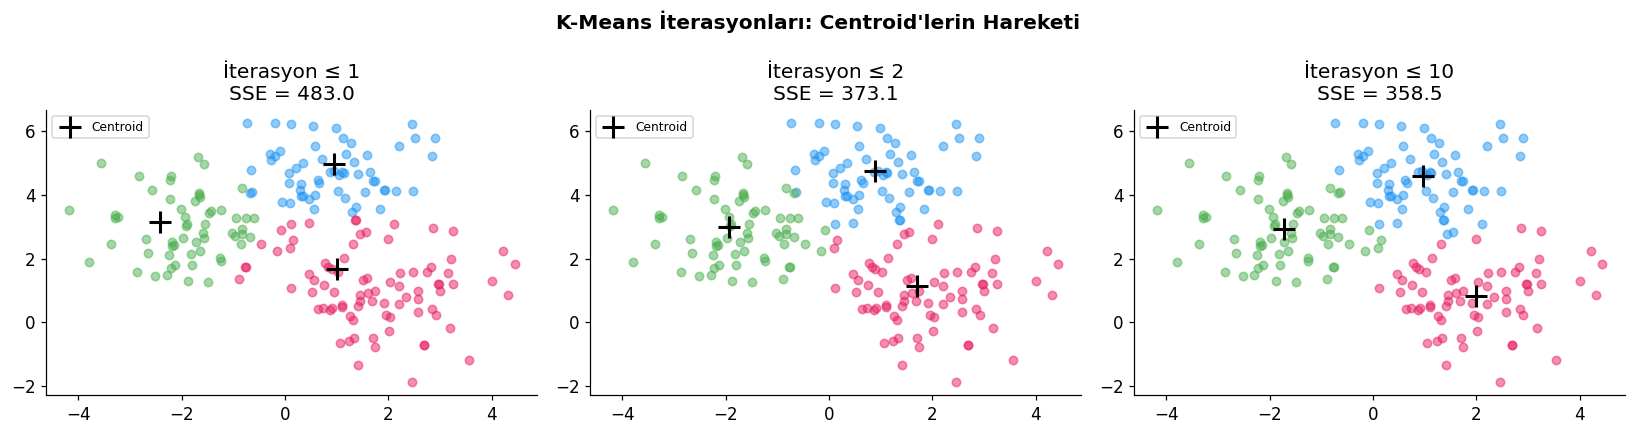

In [3]:
# ── Step-by-step K-Means visualization ──────────────────────────────────
np.random.seed(0)
X_km, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_iter = [PALETTE[0], PALETTE[1], PALETTE[2]]

for ax_idx, n_iter in enumerate([1, 2, 10]):
    km = KMeans(n_clusters=3, max_iter=n_iter, n_init=1,
                init="random", random_state=42)
    km.fit(X_km)
    labels    = km.labels_
    centroids = km.cluster_centers_

    ax = axes[ax_idx]
    for k in range(3):
        mask = labels == k
        ax.scatter(X_km[mask, 0], X_km[mask, 1],
                   color=colors_iter[k], alpha=0.5, s=30)
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c="black", marker="+", s=200, linewidths=2, zorder=5, label="Centroid")
    sse = km.inertia_
    ax.set_title(f"Iteration ≤ {n_iter}\nSSE = {sse:.1f}")
    ax.legend(fontsize=8)

plt.suptitle("K-Means Iterations: Movement of Centroids", fontweight="bold")
plt.tight_layout()
plt.show()


### 2.2 Initial Centroid Selection: Random vs K-Means++


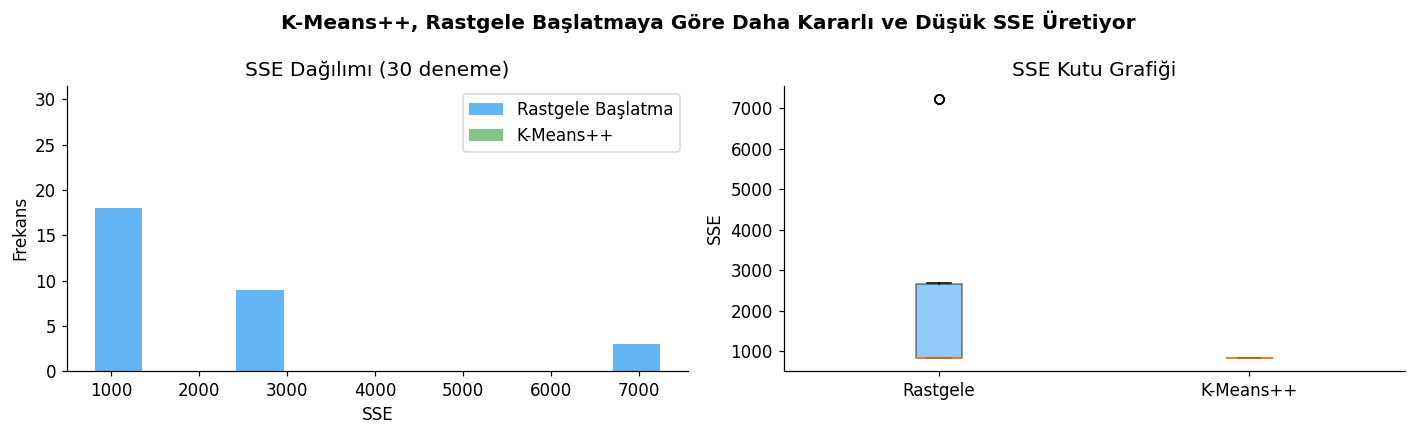

Rastgele — Ort. SSE: 2016.9 ± 1924.7
K-Means++ — Ort. SSE: 822.7    ± 0.0


In [4]:
# Random initialization vs K-Means++ comparison
np.random.seed(7)
X_init, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=7)

sse_random, sse_pp = [], []
TRIALS = 30

for seed in range(TRIALS):
    km_rand = KMeans(n_clusters=4, init="random", n_init=1, random_state=seed)
    km_rand.fit(X_init)
    sse_random.append(km_rand.inertia_)

    km_pp = KMeans(n_clusters=4, init="k-means++", n_init=1, random_state=seed)
    km_pp.fit(X_init)
    sse_pp.append(km_pp.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sse_random, bins=12, color=PALETTE[0], alpha=0.7, label="Random Init")
axes[0].hist(sse_pp,     bins=12, color=PALETTE[2], alpha=0.7, label="K-Means++")
axes[0].set_xlabel("SSE"); axes[0].set_ylabel("Frequency")
axes[0].set_title("SSE Distribution (30 trials)")
axes[0].legend()

axes[1].boxplot([sse_random, sse_pp], labels=["Random", "K-Means++"],
                patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.5))
axes[1].set_ylabel("SSE"); axes[1].set_title("SSE Box Plot")

plt.suptitle("K-Means++ Produces More Stable and Lower SSE Than Random Initialization",
             fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Random  — Avg SSE: {np.mean(sse_random):.1f} ± {np.std(sse_random):.1f}")
print(f"K-Means++ — Avg SSE: {np.mean(sse_pp):.1f}    ± {np.std(sse_pp):.1f}")


### 2.3 Optimal K Selection: SSE Elbow + Silhouette


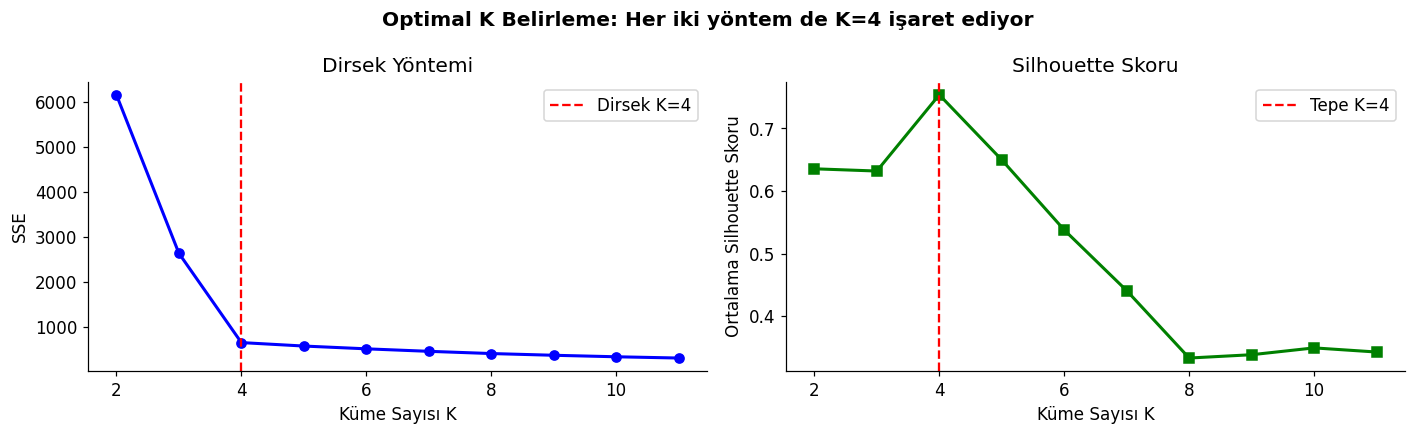

In [5]:
X_opt, _ = make_blobs(n_samples=400, centers=4, cluster_std=0.9, random_state=3)

k_range = range(2, 12)
sse_list, sil_list = [], []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_opt)
    sse_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_opt, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), sse_list, "bo-", linewidth=2)
axes[0].axvline(4, color="red", linestyle="--", label="Elbow K=4")
axes[0].set_xlabel("Number of Clusters K"); axes[0].set_ylabel("SSE")
axes[0].set_title("Elbow Method"); axes[0].legend()

axes[1].plot(list(k_range), sil_list, "gs-", linewidth=2)
opt_k = list(k_range)[np.argmax(sil_list)]
axes[1].axvline(opt_k, color="red", linestyle="--", label=f"Peak K={opt_k}")
axes[1].set_xlabel("Number of Clusters K"); axes[1].set_ylabel("Average Silhouette Score")
axes[1].set_title("Silhouette Score"); axes[1].legend()

plt.suptitle("Optimal K Determination: Both methods indicate K=4",
             fontweight="bold")
plt.tight_layout()
plt.show()


### 2.4 Silhouette Analysis — Per-Point Inspection


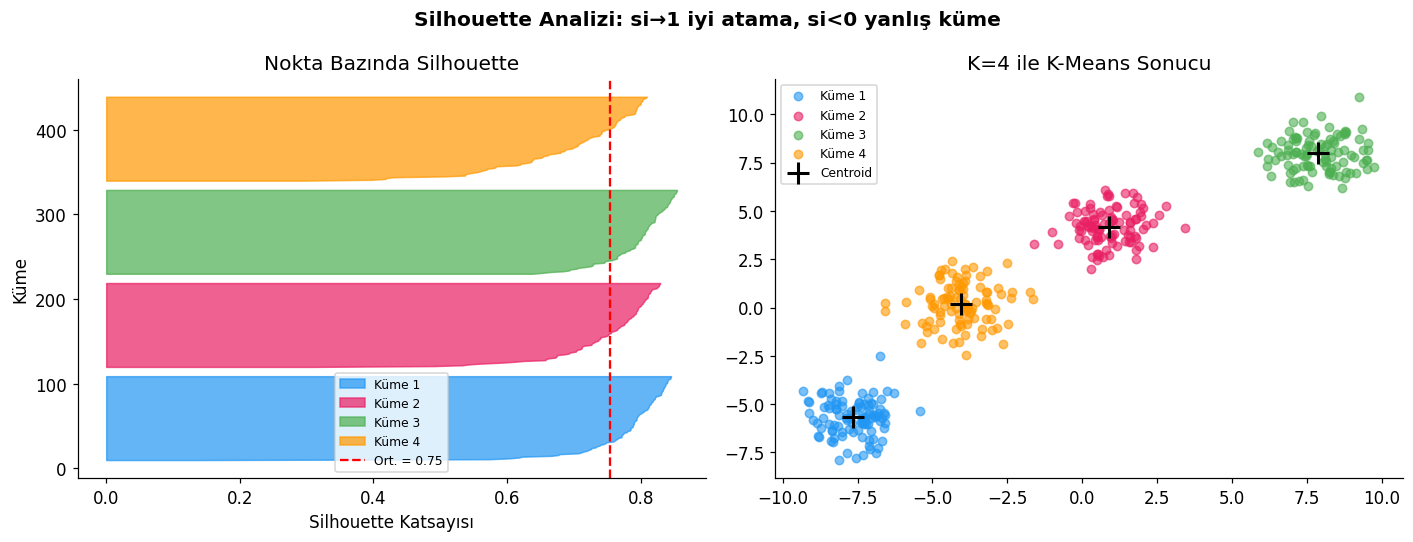

Ortalama Silhouette Skoru: 0.754


In [6]:
K_BEST = 4
km_best = KMeans(n_clusters=K_BEST, init="k-means++", n_init=10, random_state=42)
labels_best = km_best.fit_predict(X_opt)
sil_vals = silhouette_samples(X_opt, labels_best)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
y_lower = 10

for k in range(K_BEST):
    vals_k = np.sort(sil_vals[labels_best == k])
    size_k = vals_k.shape[0]
    y_upper = y_lower + size_k
    axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, vals_k,
                          alpha=0.7, color=PALETTE[k], label=f"Cluster {k+1}")
    y_lower = y_upper + 10

axes[0].axvline(np.mean(sil_vals), color="red", linestyle="--",
                label=f"Avg = {np.mean(sil_vals):.2f}")
axes[0].set_xlabel("Silhouette Coefficient"); axes[0].set_ylabel("Cluster")
axes[0].set_title("Per-Point Silhouette"); axes[0].legend(fontsize=8)

for k in range(K_BEST):
    mask = labels_best == k
    axes[1].scatter(X_opt[mask, 0], X_opt[mask, 1],
                    color=PALETTE[k], alpha=0.6, s=30, label=f"Cluster {k+1}")
axes[1].scatter(km_best.cluster_centers_[:, 0], km_best.cluster_centers_[:, 1],
                c="black", marker="+", s=200, linewidths=2, zorder=5, label="Centroid")
axes[1].set_title("K-Means Result with K=4"); axes[1].legend(fontsize=8)

plt.suptitle("Silhouette Analysis: si→1 good assignment, si<0 wrong cluster", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Average Silhouette Score: {np.mean(sil_vals):.3f}")


### 2.5 K-Means Limitations: Non-Spherical Clusters


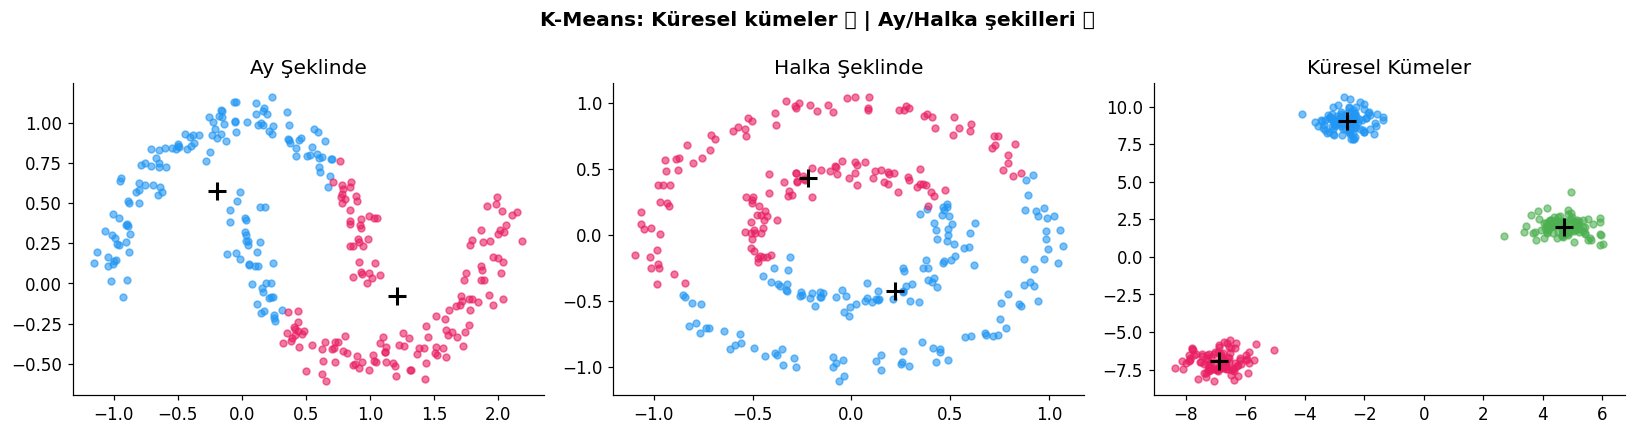

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = {
    "Moon-Shaped":    make_moons(n_samples=300, noise=0.07, random_state=42),
    "Ring-Shaped":    make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42),
    "Spherical Blobs": make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42),
}

for ax, (title, (X_d, _)) in zip(axes, datasets.items()):
    km_d = KMeans(n_clusters=2 if "Spherical" not in title else 3,
                  n_init=10, random_state=42)
    labels_d = km_d.fit_predict(X_d)
    for k in np.unique(labels_d):
        mask = labels_d == k
        ax.scatter(X_d[mask, 0], X_d[mask, 1], color=PALETTE[k], alpha=0.6, s=20)
    ax.scatter(km_d.cluster_centers_[:, 0], km_d.cluster_centers_[:, 1],
               c="black", marker="+", s=150, linewidths=2)
    ax.set_title(title)

plt.suptitle("K-Means: Spherical clusters ✅ | Moon/Ring shapes ❌", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 3. Hierarchical Clustering (Agglomerative)

Hierarchical clustering builds a tree structure (dendrogram) of nested clusters.  
K does not need to be specified in advance; the desired K is obtained by cutting the dendrogram with a horizontal line.

**Linkage methods:**  
- `single` → MIN (single linkage) — risk of chaining effect  
- `complete` → MAX (complete linkage) — compact clusters  
- `average` → UPGMA — balanced  
- `ward` → minimizes SSE increase, generally best result


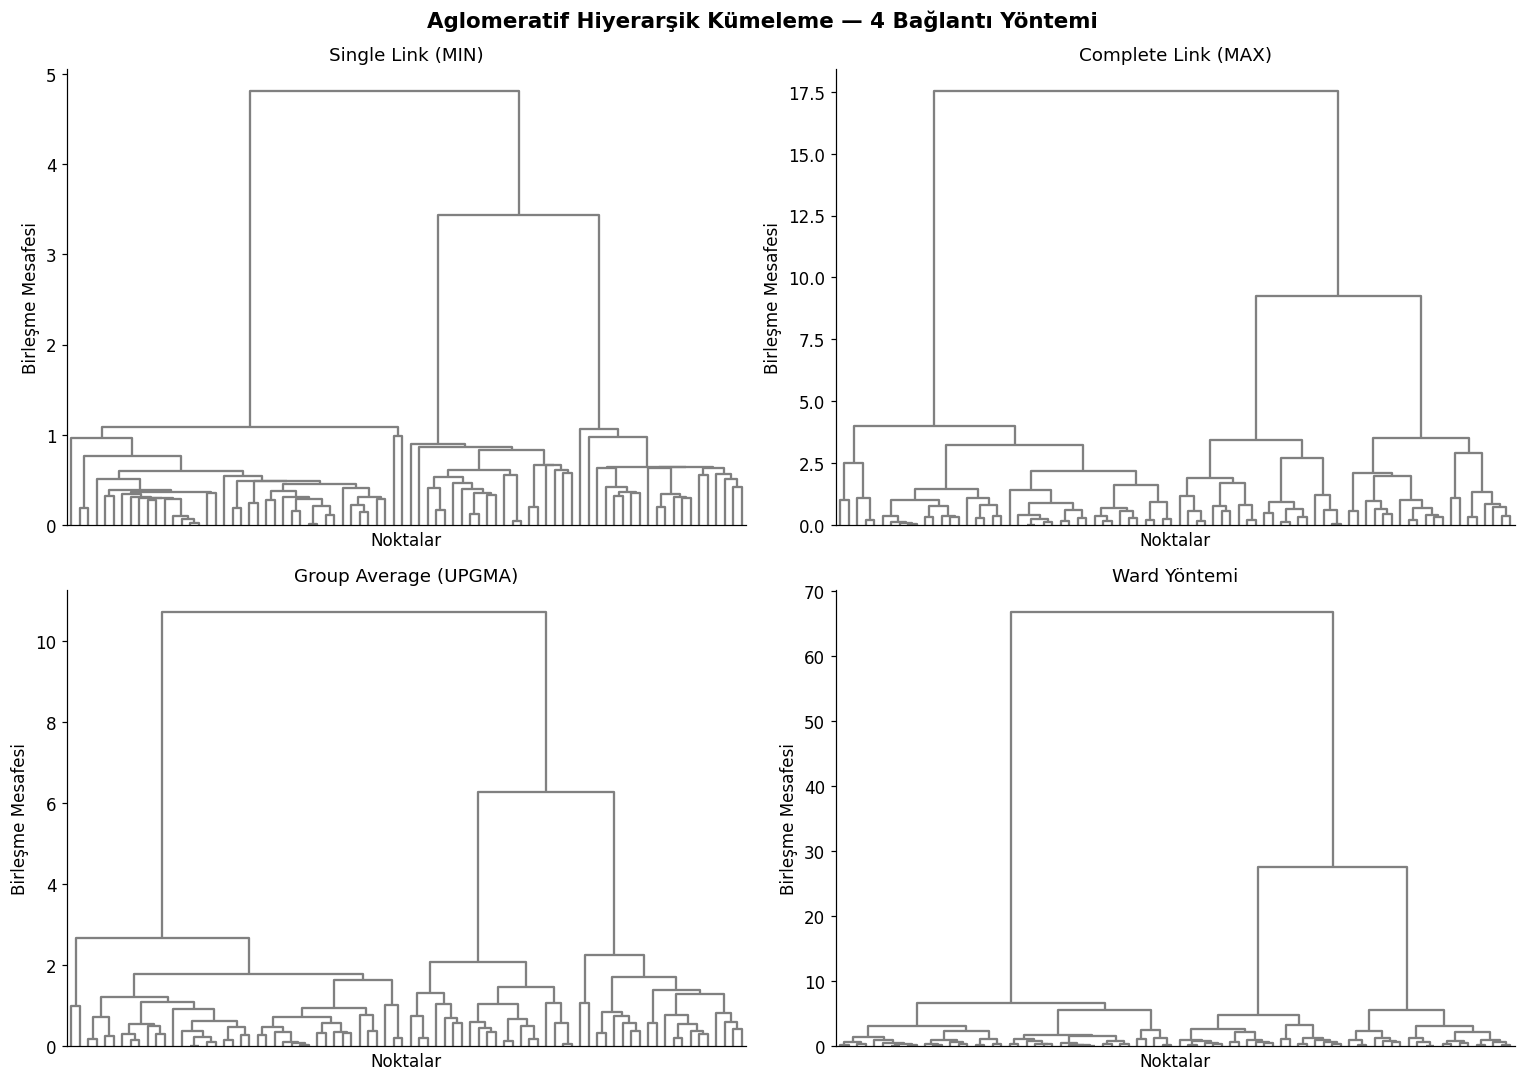

In [8]:
np.random.seed(5)
X_hier, y_hier = make_blobs(n_samples=80, centers=4,
                             cluster_std=0.8, random_state=5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
methods = ["single", "complete", "average", "ward"]
titles  = ["Single Link (MIN)", "Complete Link (MAX)",
           "Group Average (UPGMA)", "Ward Method"]

for ax, method, title in zip(axes.ravel(), methods, titles):
    Z = linkage(X_hier, method=method)
    dendrogram(Z, ax=ax, color_threshold=0, above_threshold_color="grey",
               no_labels=True)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Points"); ax.set_ylabel("Merge Distance")

plt.suptitle("Agglomerative Hierarchical Clustering — 4 Linkage Methods", fontsize=14,
             fontweight="bold")
plt.tight_layout()
plt.show()


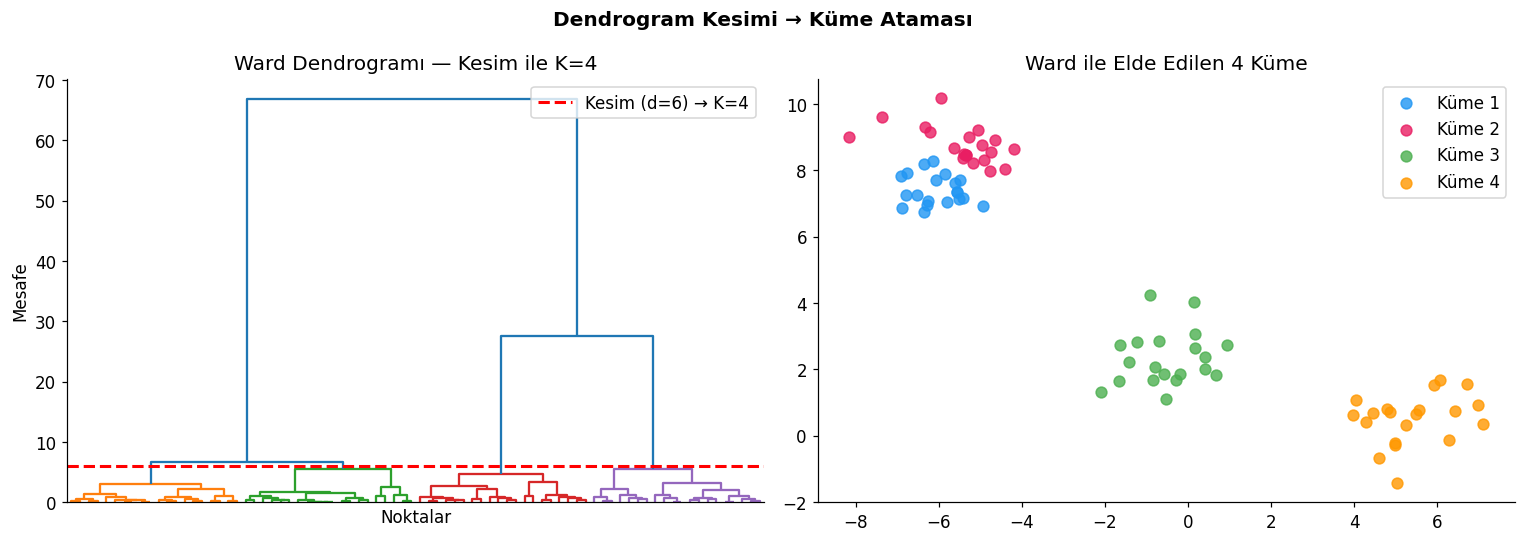

Ward — Silhouette Skoru: 0.574


In [9]:
# Cutting the Ward dendrogram to obtain 4 clusters
Z_ward = linkage(X_hier, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dendrogram + cut line
dn = dendrogram(Z_ward, ax=axes[0], color_threshold=6, no_labels=True)
axes[0].axhline(y=6, color="red", linestyle="--", linewidth=2, label="Cut (d=6) → K=4")
axes[0].set_title("Ward Dendrogram — K=4 via Cut")
axes[0].legend(); axes[0].set_xlabel("Points"); axes[0].set_ylabel("Distance")

# Cluster assignment
labels_hier = fcluster(Z_ward, t=4, criterion="maxclust") - 1
for k in range(4):
    mask = labels_hier == k
    axes[1].scatter(X_hier[mask, 0], X_hier[mask, 1],
                    color=PALETTE[k], s=50, alpha=0.8, label=f"Cluster {k+1}")
axes[1].set_title("4 Clusters Obtained via Ward")
axes[1].legend()

plt.suptitle("Dendrogram Cut → Cluster Assignment", fontweight="bold")
plt.tight_layout()
plt.show()

sil_hier = silhouette_score(X_hier, labels_hier)
print(f"Ward — Silhouette Score: {sil_hier:.3f}")


---
## 4. DBSCAN — Density-Based Clustering

DBSCAN uses two parameters:
- **ε (eps):** Neighborhood radius
- **MinPts:** Minimum number of neighbors required to be considered a core point

Each point falls into one of three categories:
- **Core:** Has ≥ MinPts neighbors within ε
- **Border:** Not a core point but within ε of a core point
- **Noise:** Neither core nor border


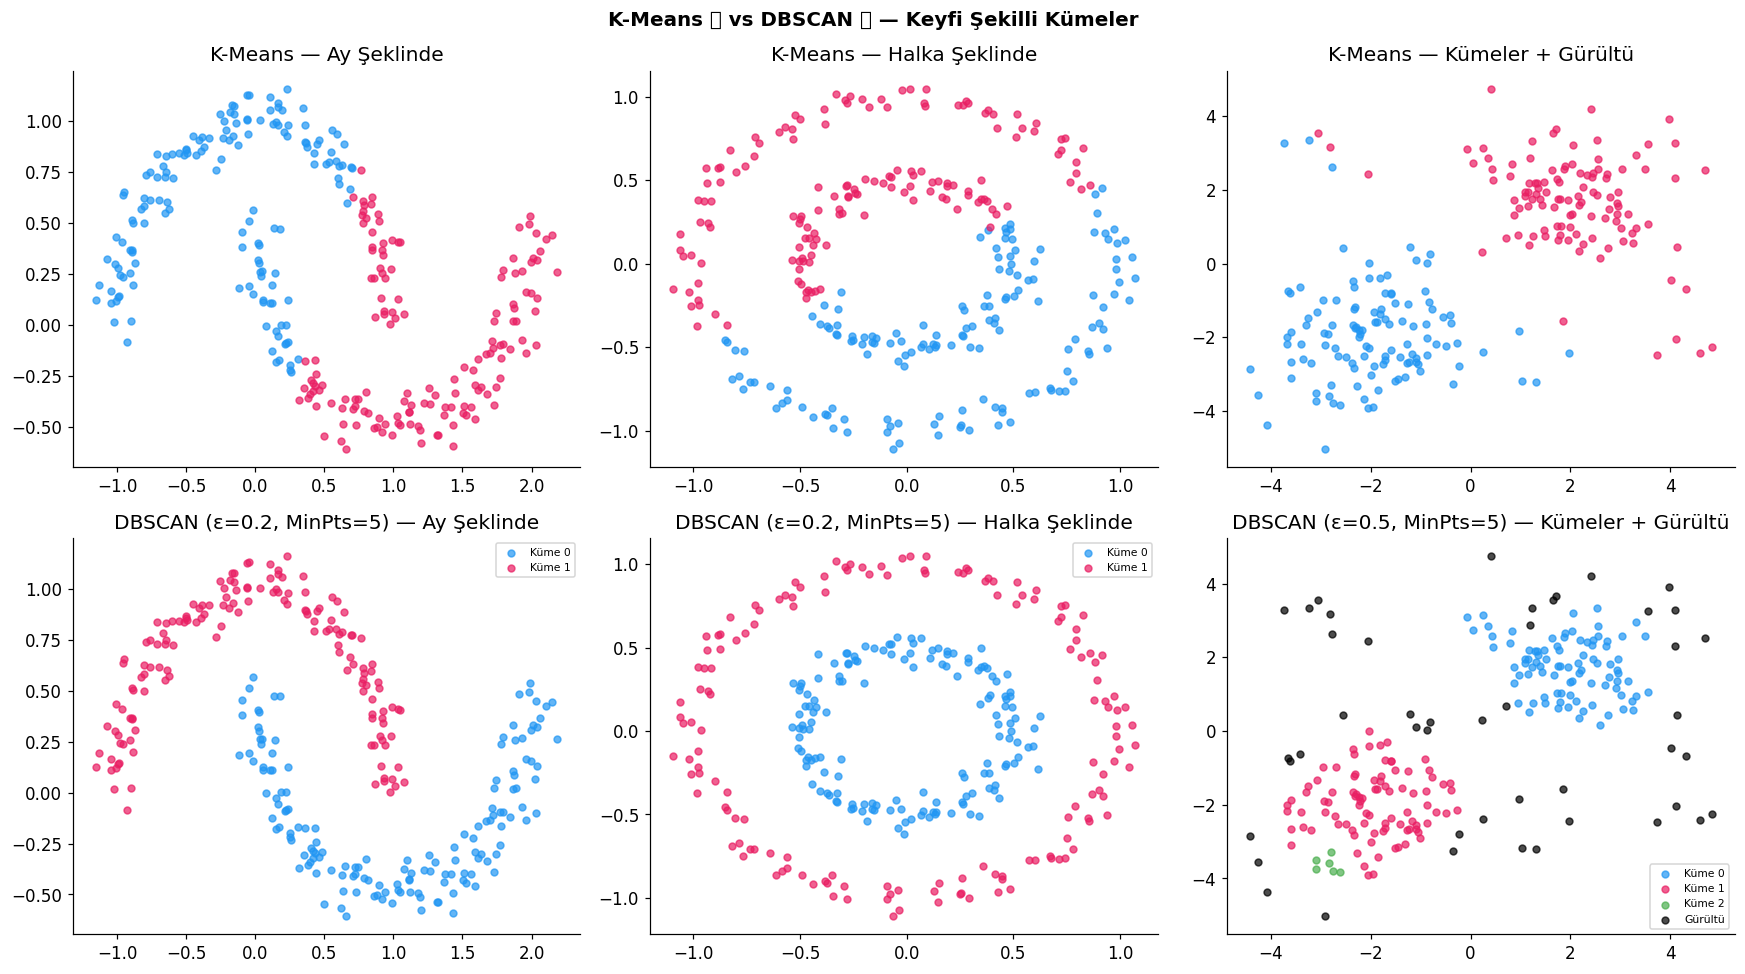

In [10]:
# DBSCAN — comparison on shapes where K-Means fails
np.random.seed(19)  # for reproducibility
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

datasets_db = [
    ("Moon-Shaped",   make_moons(n_samples=300, noise=0.07, random_state=42)),
    ("Ring-Shaped",   make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)),
    ("Clusters + Noise", (np.vstack([
        np.random.randn(100, 2) + [2, 2],
        np.random.randn(100, 2) + [-2, -2],
        np.random.uniform(-5, 5, (30, 2))   # noise
    ]), None)),
]
params = [(0.2, 5), (0.2, 5), (0.5, 5)]

for col, ((title, (X_d, _)), (eps, mpts)) in enumerate(zip(datasets_db, params)):
    # K-Means
    km_d = KMeans(n_clusters=2, n_init=10, random_state=42)
    lkm  = km_d.fit_predict(X_d)
    for k in np.unique(lkm):
        axes[0][col].scatter(X_d[lkm==k, 0], X_d[lkm==k, 1],
                             color=PALETTE[k], s=20, alpha=0.7)
    axes[0][col].set_title(f"K-Means — {title}")

    # DBSCAN
    db  = DBSCAN(eps=eps, min_samples=mpts)
    ldb = db.fit_predict(X_d)
    unique_labels = set(ldb)
    color_map = {lbl: (PALETTE[i % len(PALETTE)] if lbl != -1 else "black")
                 for i, lbl in enumerate(unique_labels)}
    for lbl in unique_labels:
        mask      = ldb == lbl
        label_str = f"Cluster {lbl}" if lbl != -1 else "Noise"
        axes[1][col].scatter(X_d[mask, 0], X_d[mask, 1],
                             color=color_map[lbl], s=20, alpha=0.7, label=label_str)
    axes[1][col].set_title(f"DBSCAN (ε={eps}, MinPts={mpts}) — {title}")
    axes[1][col].legend(fontsize=7)

plt.suptitle("K-Means ❌ vs DBSCAN ✅ — Arbitrarily Shaped Clusters", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.show()


### 4.1 ε Selection — k-dist Plot


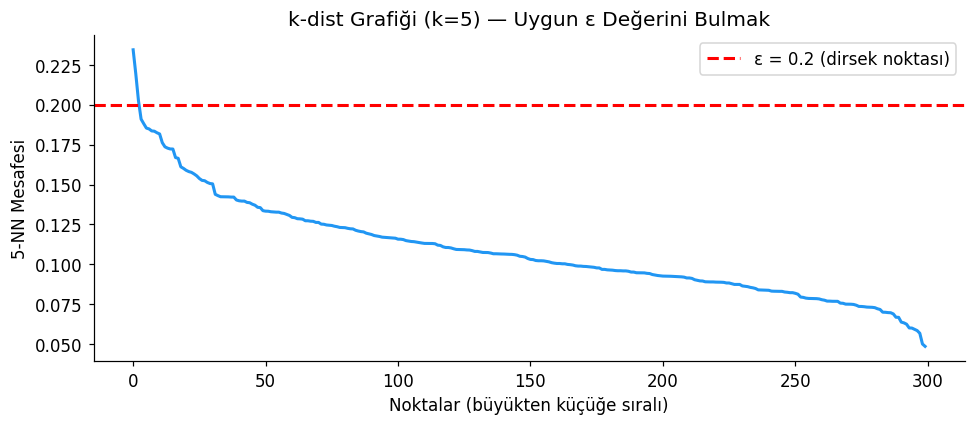

Dirsek noktasındaki ε değeri yaklaşık 0.20 olarak belirlendi.


In [11]:
X_moon, _ = make_moons(n_samples=300, noise=0.07, random_state=42)
k_nn = 5

nbrs = NearestNeighbors(n_neighbors=k_nn + 1).fit(X_moon)
distances, _ = nbrs.kneighbors(X_moon)
k_distances  = np.sort(distances[:, k_nn])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color=PALETTE[0], linewidth=2)
ax.axhline(y=0.2, color="red", linestyle="--", linewidth=2,
           label="ε = 0.2 (elbow point)")
ax.set_xlabel("Points (sorted descending)")
ax.set_ylabel(f"{k_nn}-NN Distance")
ax.set_title(f"k-dist Plot (k={k_nn}) — Finding a Suitable ε Value")
ax.legend()
plt.tight_layout()
plt.show()
print("ε value at the elbow point determined to be approximately 0.20.")


### 4.2 Effect of ε and MinPts


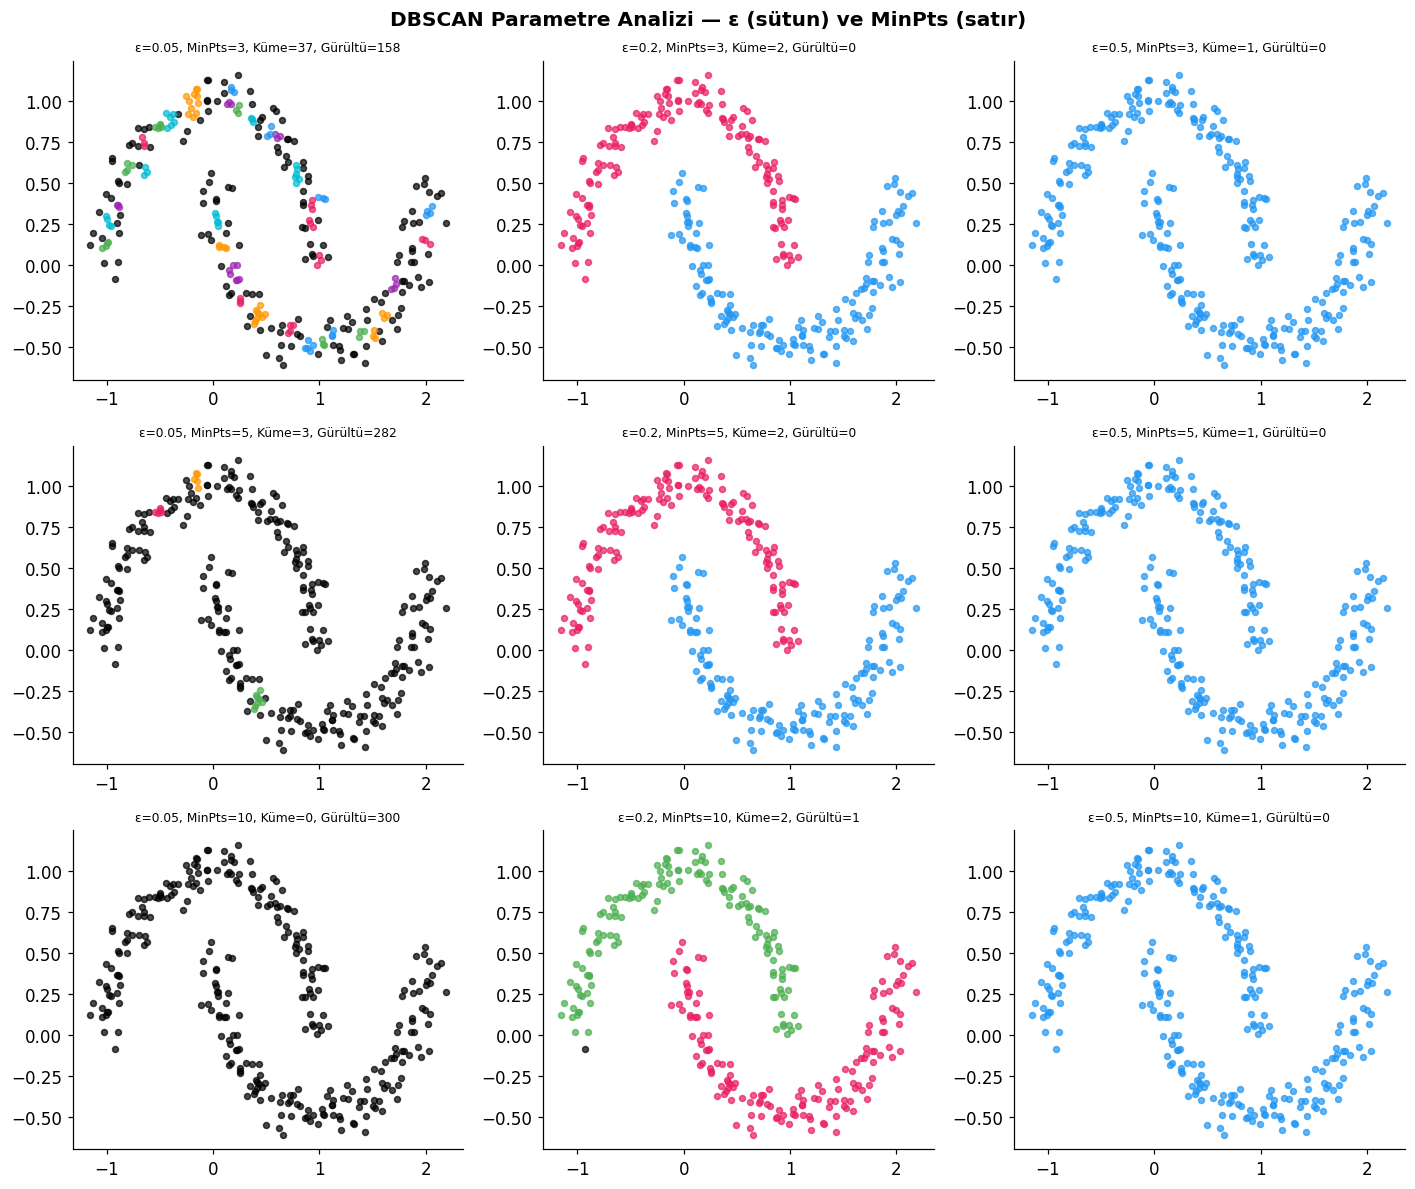

In [12]:
X_db_test, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

eps_vals  = [0.05, 0.2, 0.5]
mpts_vals = [3, 5, 10]

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for r, mpts in enumerate(mpts_vals):
    for c, eps in enumerate(eps_vals):
        db = DBSCAN(eps=eps, min_samples=mpts)
        ldb = db.fit_predict(X_db_test)
        n_clusters = len(set(ldb)) - (1 if -1 in ldb else 0)
        n_noise    = np.sum(ldb == -1)
        ax = axes[r][c]
        unique = set(ldb)
        for i, lbl in enumerate(sorted(unique)):
            mask = ldb == lbl
            clr  = "black" if lbl == -1 else PALETTE[i % len(PALETTE)]
            ax.scatter(X_db_test[mask, 0], X_db_test[mask, 1],
                       c=clr, s=15, alpha=0.7)
        title_str = "ε={}, MinPts={}, Clusters={}, Noise={}".format(
            eps, mpts, n_clusters, n_noise)
        ax.set_title(title_str, fontsize=8)

plt.suptitle("DBSCAN Parameter Analysis — ε (columns) and MinPts (rows)", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 5. Cluster Evaluation

### 5.1 Unsupervised (Internal) Evaluation — SSE and Silhouette

The Silhouette coefficient for each point:
$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)} \in [-1, 1]$$

- $a_i$: average distance to points in its own cluster (smaller → better)  
- $b_i$: average distance to points in the nearest neighboring cluster (larger → better)


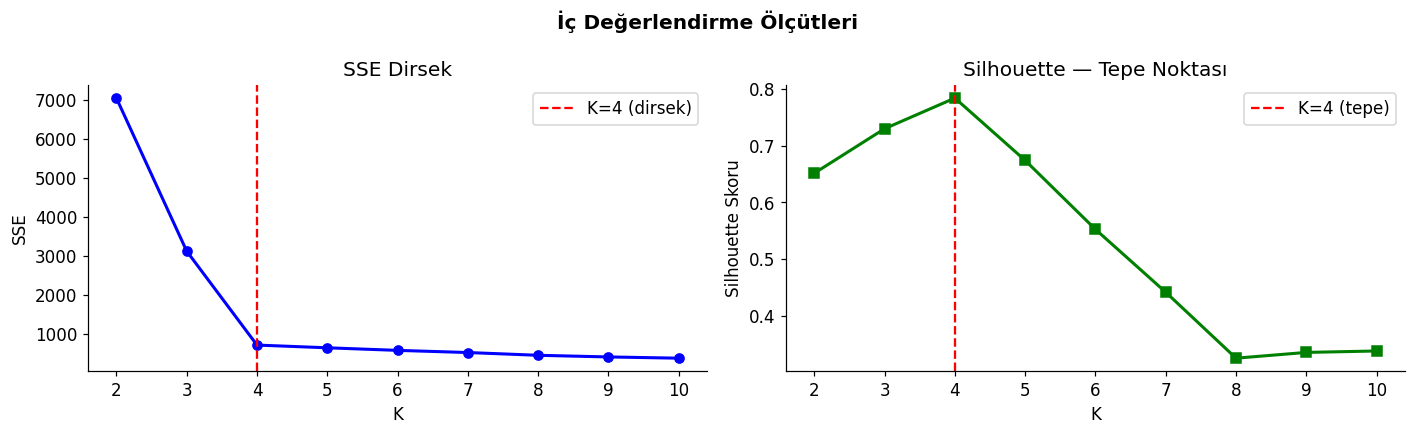

En iyi K (Silhouette): 4
En yüksek Silhouette : 0.784


In [13]:
X_eval, y_eval = make_blobs(n_samples=400, centers=4, cluster_std=1.0, random_state=10)
k_list = list(range(2, 11))
sse_e, sil_e = [], []

for k in k_list:
    km_e = KMeans(n_clusters=k, n_init=10, random_state=42)
    lbl  = km_e.fit_predict(X_eval)
    sse_e.append(km_e.inertia_)
    sil_e.append(silhouette_score(X_eval, lbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_list, sse_e, "bo-", linewidth=2)
axes[0].axvline(4, color="red", linestyle="--", label="K=4 (elbow)")
axes[0].set_xlabel("K"); axes[0].set_ylabel("SSE"); axes[0].set_title("SSE Elbow")
axes[0].legend()

axes[1].plot(k_list, sil_e, "gs-", linewidth=2)
axes[1].axvline(4, color="red", linestyle="--", label="K=4 (peak)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette — Peak Point"); axes[1].legend()

plt.suptitle("Internal Evaluation Measures", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Best K (Silhouette): {k_list[np.argmax(sil_e)]}")
print(f"Highest Silhouette : {max(sil_e):.3f}")


### 5.2 Supervised (External) Evaluation — Purity and Entropy


Oluşum Matrisi (satır=gerçek sınıf, sütun=tahmin edilen küme):
         Küme 0  Küme 1  Küme 2  Küme 3
Sınıf 0      69       0       0       6
Sınıf 1       0       0      75       0
Sınıf 2       2       0       0      73
Sınıf 3       0      75       0       0

Saflık (Purity)     : 0.973
Entropi (Ağırlıklı) : 0.146


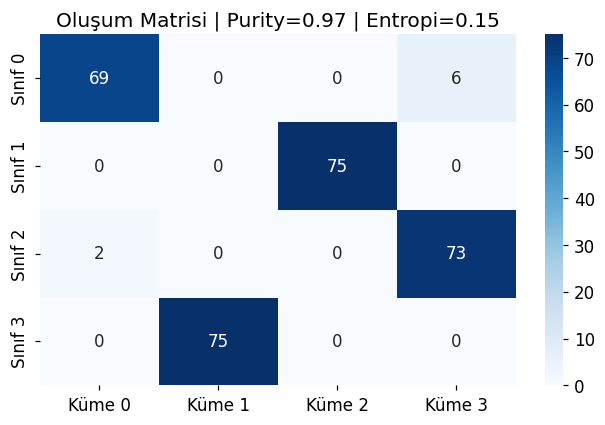

In [14]:
X_sup, y_sup = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=99)
km_sup = KMeans(n_clusters=4, n_init=10, random_state=42)
pred   = km_sup.fit_predict(X_sup)

ct = contingency_matrix(y_sup, pred)
print("Contingency Matrix (rows=true class, columns=predicted cluster):")
print(pd.DataFrame(ct, index=[f"Class {i}" for i in range(4)],
                   columns=[f"Cluster {j}" for j in range(4)]))
print()

# Purity
purity = np.sum(np.max(ct, axis=0)) / np.sum(ct)
print(f"Purity              : {purity:.3f}")

# Entropy (weighted average)
total = np.sum(ct)
entropy_total = 0
for j in range(ct.shape[1]):
    col = ct[:, j]
    n_j = np.sum(col)
    if n_j == 0: continue
    p   = col / n_j
    p   = p[p > 0]
    entropy_j      = -np.sum(p * np.log2(p))
    entropy_total += (n_j / total) * entropy_j
print(f"Entropy (Weighted)  : {entropy_total:.3f}")

# Visualization
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=[f"Cluster {j}" for j in range(4)],
            yticklabels=[f"Class {i}" for i in range(4)])
ax.set_title(f"Contingency Matrix | Purity={purity:.2f} | Entropy={entropy_total:.2f}")
plt.tight_layout()
plt.show()


---
## 6. Anomaly Detection

> **Anomaly:** An observation that is inconsistent with the distribution formed by normal samples; an observation that is unlikely under that distribution.

Key scenarios:
- **Noise** → data quality issue; we want to remove it  
- **True anomaly** → rare but real event; we want to detect it


### 6.1 Statistical Approach — z-Score and Gaussian


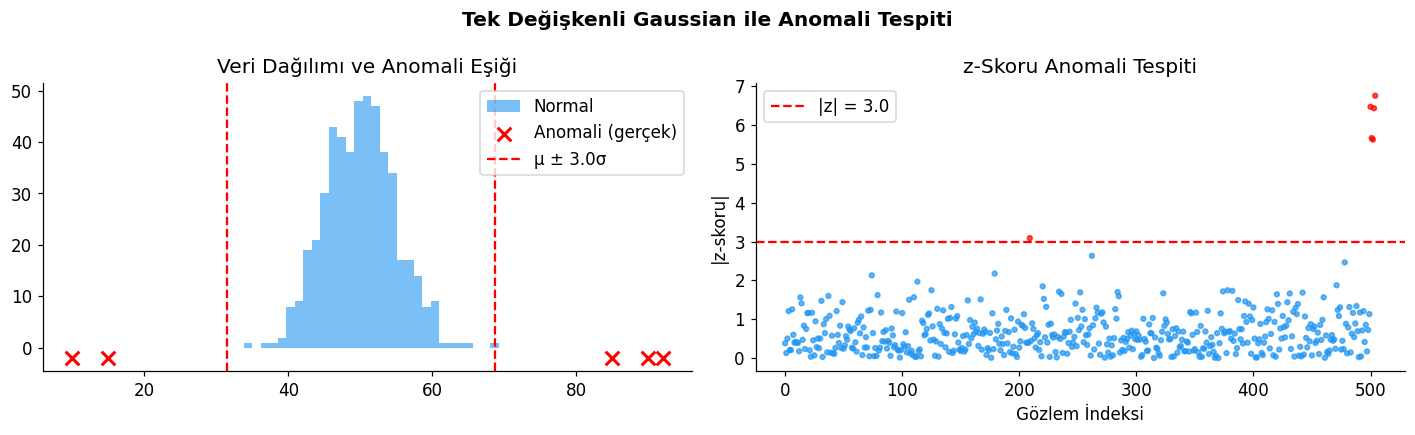

Tespit edilen anomali sayısı: 6
Tespit edilen değerler: [69.3 10.  15.  85.  90.  92. ]


In [15]:
np.random.seed(42)
normal_data = np.random.normal(loc=50, scale=5, size=500)
anomalies   = np.array([10, 15, 85, 90, 92])
data_all    = np.concatenate([normal_data, anomalies])

mu, sigma = data_all.mean(), data_all.std()
z_scores  = np.abs(zscore(data_all))
threshold = 3.0
detected  = data_all[z_scores >= threshold]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution + anomalies
axes[0].hist(normal_data, bins=30, color=PALETTE[0], alpha=0.6, label="Normal")
axes[0].scatter(anomalies, np.zeros_like(anomalies) - 2, color="red",
                s=80, marker="x", linewidths=2, label="Anomaly (true)")
axes[0].axvline(mu + threshold * sigma, color="red", linestyle="--",
                label=f"μ ± {threshold}σ")
axes[0].axvline(mu - threshold * sigma, color="red", linestyle="--")
axes[0].set_title("Data Distribution and Anomaly Threshold")
axes[0].legend()

# z-score plot
axes[1].scatter(range(len(data_all)), z_scores, c=["red" if z >= threshold else PALETTE[0]
                for z in z_scores], s=10, alpha=0.7)
axes[1].axhline(threshold, color="red", linestyle="--", label=f"|z| = {threshold}")
axes[1].set_xlabel("Observation Index"); axes[1].set_ylabel("|z-score|")
axes[1].set_title("z-Score Anomaly Detection"); axes[1].legend()

plt.suptitle("Univariate Anomaly Detection with Gaussian", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Number of anomalies detected: {len(detected)}")
print(f"Detected values: {np.round(detected, 1)}")


### 6.2 Mahalanobis Distance — Multivariate Anomaly Detection


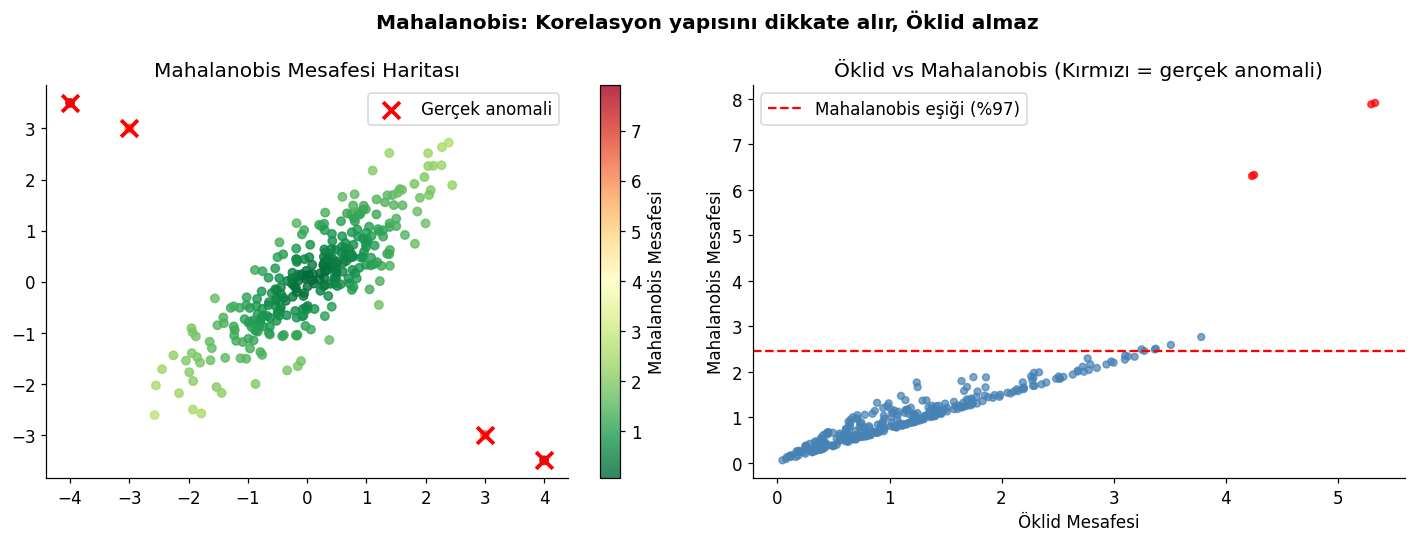

In [16]:
np.random.seed(0)
# Correlated normal data
cov   = [[1, 0.85], [0.85, 1]]
X_mah = np.random.multivariate_normal([0, 0], cov, 300)
# Anomalies: points that break the correlation pattern
anom_pts = np.array([[-3, 3], [3, -3], [-4, 3.5], [4, -3.5]])
X_all    = np.vstack([X_mah, anom_pts])

mu_mah = X_all.mean(axis=0)
S_inv  = np.linalg.inv(np.cov(X_all.T))

def mahalanobis(x, mu, S_inv):
    diff = x - mu
    return np.sqrt(diff @ S_inv @ diff.T)

mah_dists  = np.array([mahalanobis(pt, mu_mah, S_inv) for pt in X_all])
euc_dists  = np.linalg.norm(X_all - mu_mah, axis=1)
mah_thresh = np.percentile(mah_dists, 97)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: color = Mahalanobis distance
sc = axes[0].scatter(X_all[:, 0], X_all[:, 1], c=mah_dists,
                     cmap="RdYlGn_r", s=30, alpha=0.8)
axes[0].scatter(anom_pts[:, 0], anom_pts[:, 1], c="red", marker="x",
                s=120, linewidths=2.5, label="True anomaly", zorder=5)
plt.colorbar(sc, ax=axes[0], label="Mahalanobis Distance")
axes[0].set_title("Mahalanobis Distance Map")
axes[0].legend()

# Euclidean vs Mahalanobis comparison
axes[1].scatter(euc_dists, mah_dists, c=["red" if i >= len(X_mah)
               else "steelblue" for i in range(len(X_all))], s=20, alpha=0.7)
axes[1].axhline(mah_thresh, color="red", linestyle="--",
                label=f"Mahalanobis threshold (97th pct)")
axes[1].set_xlabel("Euclidean Distance"); axes[1].set_ylabel("Mahalanobis Distance")
axes[1].set_title("Euclidean vs Mahalanobis (Red = true anomaly)")
axes[1].legend()

plt.suptitle("Mahalanobis: Accounts for correlation structure, Euclidean does not", fontweight="bold")
plt.tight_layout()
plt.show()


### 6.3 LOF — Local Outlier Factor


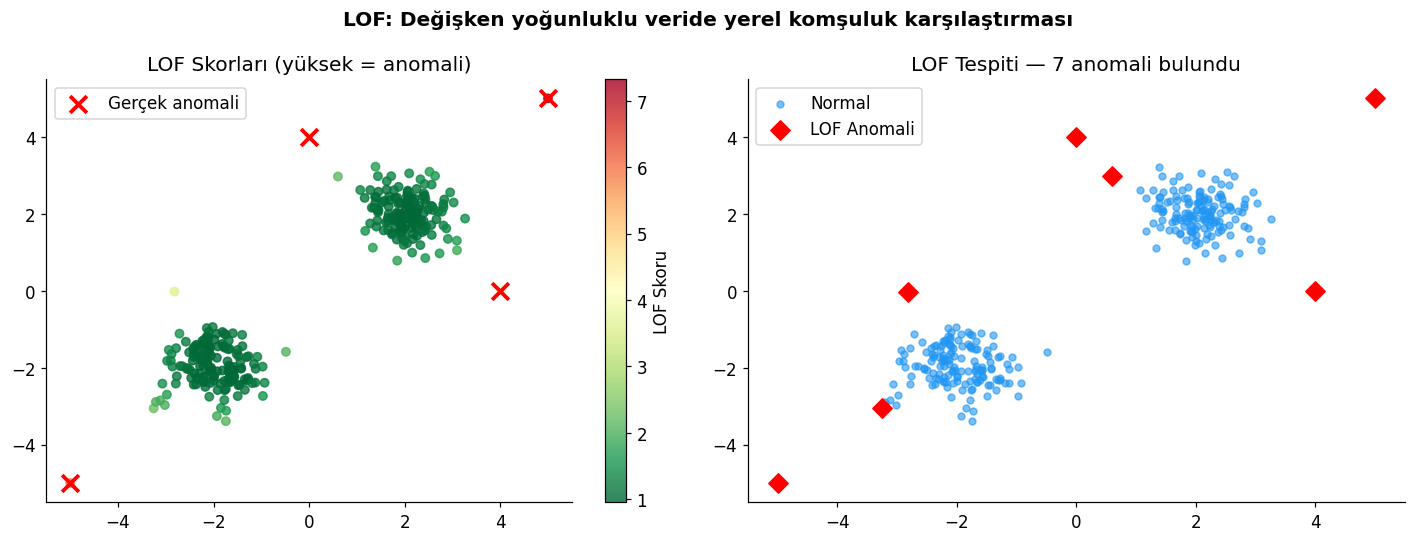

In [17]:
np.random.seed(1)
X_lof_a = np.random.randn(150, 2) * 0.5 + [2, 2]
X_lof_b = np.random.randn(150, 2) * 0.5 + [-2, -2]
X_anom  = np.array([[5, 5], [-5, -5], [0, 4], [4, 0]])
X_lof   = np.vstack([X_lof_a, X_lof_b, X_anom])

lof    = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
y_lof  = lof.fit_predict(X_lof)          # -1: anomaly, 1: normal
scores = -lof.negative_outlier_factor_   # larger → more anomalous

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(X_lof[:, 0], X_lof[:, 1], c=scores,
                     cmap="RdYlGn_r", s=30, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label="LOF Score")
axes[0].scatter(X_anom[:, 0], X_anom[:, 1], c="red", marker="x",
                s=120, linewidths=2.5, zorder=5, label="True anomaly")
axes[0].set_title("LOF Scores (higher = more anomalous)"); axes[0].legend()

normal_mask = y_lof == 1
anom_mask   = y_lof == -1
axes[1].scatter(X_lof[normal_mask, 0], X_lof[normal_mask, 1],
                color=PALETTE[0], s=20, alpha=0.6, label="Normal")
axes[1].scatter(X_lof[anom_mask, 0], X_lof[anom_mask, 1],
                color="red", s=80, marker="D", label="LOF Anomaly")
axes[1].set_title(f"LOF Detection — {anom_mask.sum()} anomalies found")
axes[1].legend()

plt.suptitle("LOF: Local neighborhood comparison for varying-density data",
             fontweight="bold")
plt.tight_layout()
plt.show()


### 6.4 Anomaly Detection via PCA Reconstruction Error


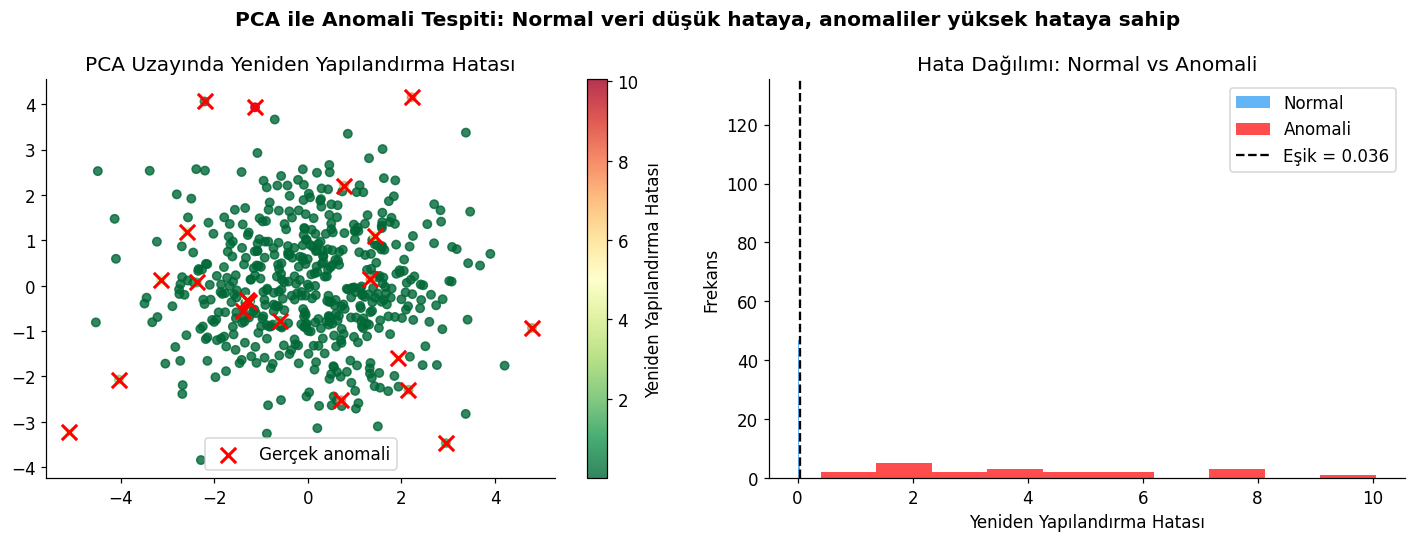

20 gerçek anomaliden tespit edilen: 20 (100%)


In [18]:
np.random.seed(7)
# Normal data: 5-dimensional, lives in a low-dimensional subspace
X_base = np.random.randn(500, 2) @ np.random.randn(2, 5)
X_base += np.random.randn(*X_base.shape) * 0.1
# Anomalies: random 5D points
X_anom_pca = np.random.randn(20, 5) * 3
X_pca_all  = np.vstack([X_base, X_anom_pca])
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(X_pca_all)

pca = PCA(n_components=2)
X_reduced       = pca.fit_transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_reduced)
recon_errors    = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

threshold_pca = np.percentile(recon_errors[:500], 97)
detected_pca  = recon_errors > threshold_pca

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc2 = axes[0].scatter(X_reduced[:, 0], X_reduced[:, 1],
                      c=recon_errors, cmap="RdYlGn_r", s=30, alpha=0.8)
axes[0].scatter(X_reduced[500:, 0], X_reduced[500:, 1],
                c="red", marker="x", s=100, linewidths=2, zorder=5, label="True anomaly")
plt.colorbar(sc2, ax=axes[0], label="Reconstruction Error")
axes[0].set_title("Reconstruction Error in PCA Space")
axes[0].legend()

axes[1].hist(recon_errors[:500], bins=30, color=PALETTE[0], alpha=0.7, label="Normal")
axes[1].hist(recon_errors[500:], bins=10, color="red",       alpha=0.7, label="Anomaly")
axes[1].axvline(threshold_pca, color="black", linestyle="--",
                label=f"Threshold = {threshold_pca:.3f}")
axes[1].set_xlabel("Reconstruction Error"); axes[1].set_ylabel("Frequency")
axes[1].set_title("Error Distribution: Normal vs Anomaly"); axes[1].legend()

plt.suptitle("PCA Anomaly Detection: Normal data → low error, Anomalies → high error",
             fontweight="bold")
plt.tight_layout()
plt.show()

detected_anomalies = np.sum(detected_pca[500:])
print(f"Detected out of 20 true anomalies: {detected_anomalies} ({detected_anomalies/20*100:.0f}%)")


---
## 7. Algorithm Comparison

We compare three clustering algorithms across different data types.

| Algorithm  | K required? | Arbitrary shape | Noise tolerance | Time complexity |
|------------|------------|-----------------|-----------------|----------------|
| K-Means    | ✅ | ❌ | Low  | O(IKmn)      |
| Hierarchical | ❌ | Partial | Medium | O(m² log m) |
| DBSCAN     | ❌ | ✅ | High | O(m log m)*  |


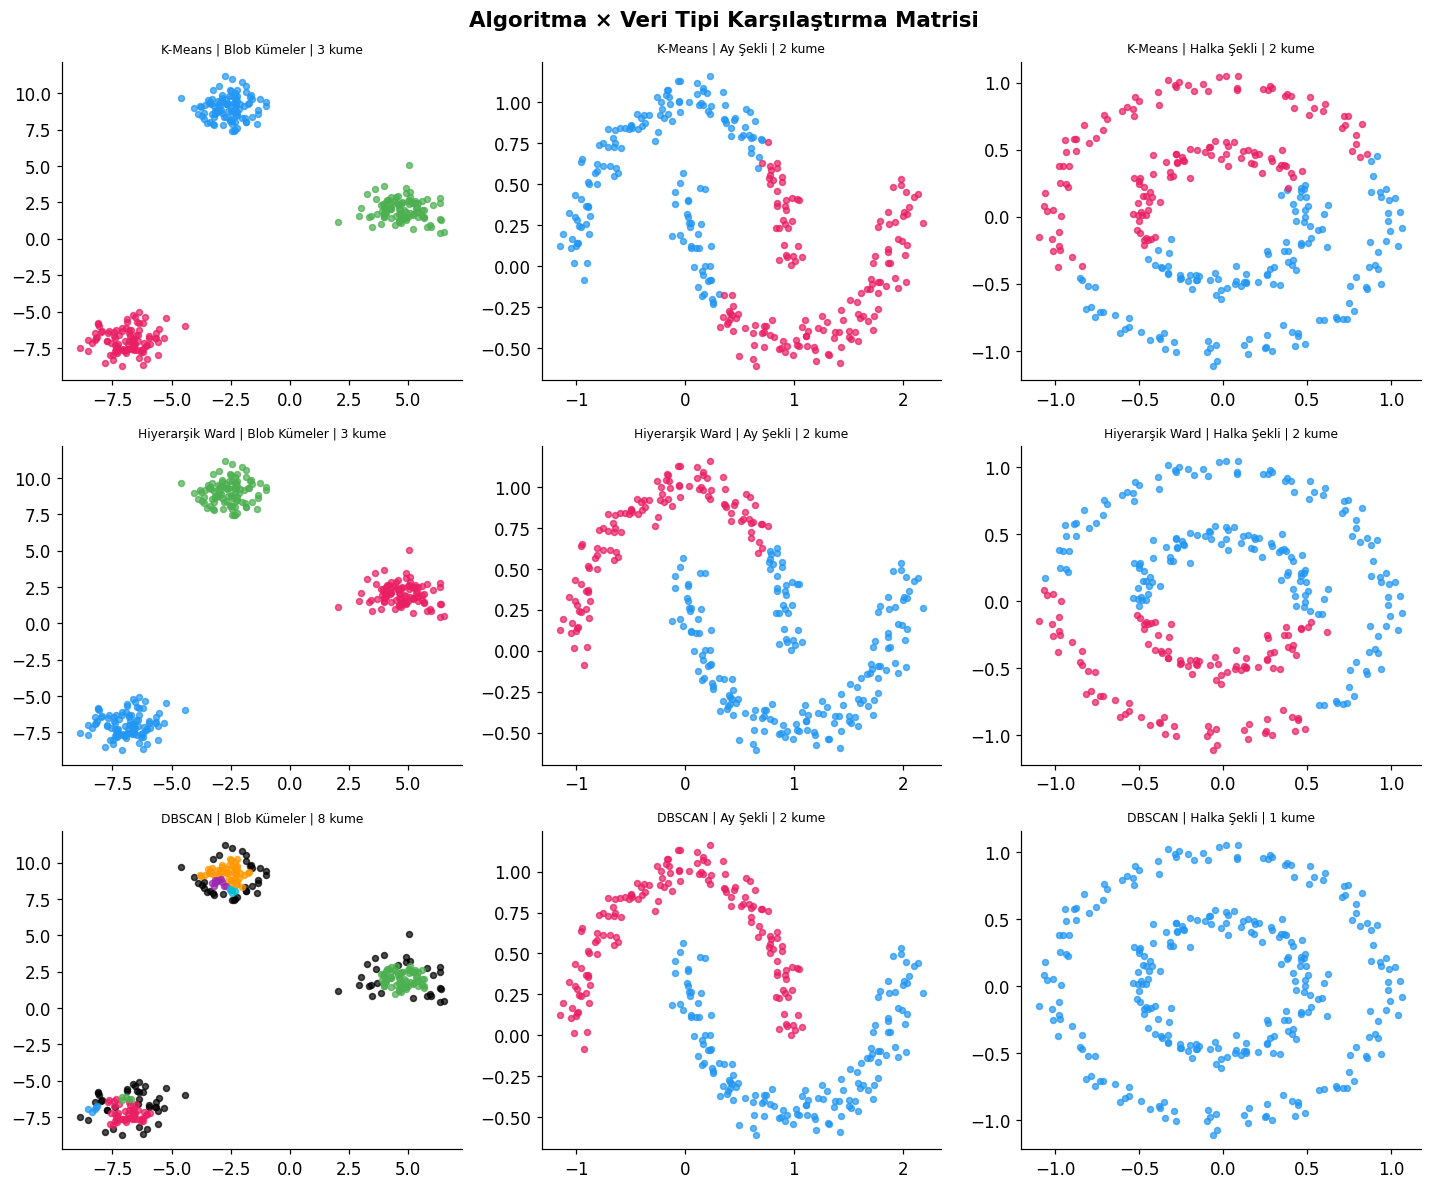

In [19]:
datasets_compare = {
    "Blob Clusters": make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42),
    "Moon Shape"   : make_moons(n_samples=300, noise=0.07, random_state=42),
    "Ring Shape"   : make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42),
}

def km_fn(X, n):
    return KMeans(n_clusters=n, n_init=10, random_state=42).fit_predict(X)
def hier_fn(X, n):
    return AgglomerativeClustering(n_clusters=n).fit_predict(X)
def db_fn(X):
    return DBSCAN(eps=0.3, min_samples=5).fit_predict(X)

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for col, (name, (X_c, _)) in enumerate(datasets_compare.items()):
    n_cl_target = 3 if "Blob" in name else 2
    alg_results = [
        ("K-Means",          km_fn(X_c, n_cl_target)),
        ("Hierarchical Ward", hier_fn(X_c, n_cl_target)),
        ("DBSCAN",            db_fn(X_c)),
    ]
    for row, (alg_name, lbl) in enumerate(alg_results):
        ax = axes[row][col]
        unique = sorted(set(lbl))
        for i, k in enumerate(unique):
            mask  = lbl == k
            color = "black" if k == -1 else PALETTE[i % len(PALETTE)]
            ax.scatter(X_c[mask, 0], X_c[mask, 1], c=color, s=15, alpha=0.7)
        n_found = len(unique) - (1 if -1 in unique else 0)
        ax.set_title("{} | {} | {} clusters".format(alg_name, name, n_found), fontsize=8)

plt.suptitle("Algorithm × Data Type Comparison Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 8. Summary and Practical Algorithm Selection Guide

| Scenario | Recommended Algorithm |
|----------|----------------------|
| Large data, spherical clusters | **K-Means** or **K-Means++** |
| Exploring hierarchical structure | **Ward** or **Complete Link** |
| Arbitrary shapes, noisy data | **DBSCAN** (or HDBSCAN for varying density) |
| Reducing initialization sensitivity | **Bisecting K-Means** |
| Evaluation | **Silhouette score** + dendrogram visualization |
| Anomaly detection (distribution known) | **z-score / Mahalanobis** |
| Anomaly detection (local density) | **LOF** |
| Anomaly detection (dimensionality reduction) | **PCA reconstruction** |

### Key Principles

1. **Cluster definition depends on data and goal** — there is no universal "correct cluster".
2. **Different algorithms assume different cluster types** — understand your data first.
3. **Evaluation is mandatory** — SSE alone is not sufficient; use Silhouette.
4. **Anomaly ≠ noise** — the goal is not always to remove; detecting is the aim.
5. **Parameter selection is critical** — K, ε, MinPts are not chosen blindly; use principled methods.


In [20]:
print("=" * 55)
print("  Data Mining Lecture 5 Notebook Complete!  ")
print("=" * 55)
print()
print("Topics Covered:")
topics = [
    "1. Introduction to Clustering",
    "2. K-Means: Algorithm, K-Means++, Elbow, Silhouette",
    "3. Hierarchical Clustering: 4 methods + Dendrogram",
    "4. DBSCAN: Parameter selection, k-dist plot",
    "5. Cluster Evaluation: Purity, Entropy",
    "6. Anomaly Detection: z-score, Mahalanobis, LOF, PCA",
    "7. Algorithm Comparison Matrix",
]
for k in topics:
    print(f"  ✅ {k}")


  Veri Madenciliği 5. Ders Notebook'u Tamamlandı!  

Kapsanan Konular:
  ✅ 1. Kümelemeye Giriş
  ✅ 2. K-Means: Algoritma, K-Means++, Dirsek, Silhouette
  ✅ 3. Hiyerarşik Kümeleme: 4 yöntem + Dendrogram
  ✅ 4. DBSCAN: Parametre seçimi, k-dist grafiği
  ✅ 5. Küme Değerlendirmesi: Purity, Entropi
  ✅ 6. Anomali Tespiti: z-skoru, Mahalanobis, LOF, PCA
  ✅ 7. Algoritma Karşılaştırma Matrisi
